In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
df_original = pd.read_excel('./datasets/dataset.xlsx')
df_original.head()

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,...,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d9e41465789c2b5,15,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Preprocessing

In [26]:
df = df_original.copy()
df.head()

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,...,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d9e41465789c2b5,15,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
df.shape

(5644, 111)

**Formatage des colonnes**

In [28]:
def format_col_name(col_name_ : str) -> str:
    """
    Formats a column name by converting it to lowercase, replacing spaces with underscores,
    and trimming unnecessary whitespace. If the input contains a parenthesis, the function
    only processes the substring before the parenthesis.

    :param col_name_: The name of the column to be formatted.
    :return: The formatted column name with spaces replaced by underscores and converted
        to lowercase.
    """
    if col_name_.find('(') == -1:
        return col_name_.strip(' ').replace(' ', '_').lower()
    return col_name_[ :col_name_.find('(')].strip(' ').replace(' ', '_').lower()

In [29]:
df.rename(columns={col : format_col_name(col) for col in df.columns}, inplace=True)

In [30]:
# Création des groupes de variables
missing_columns_a = (df.isnull().sum() * 100 / df.shape[0]).round(0) == 76
missing_columns_b = (df.isnull().sum() * 100 / df.shape[0]).round(0) == 89

respiratory_pathogens = list(df.columns[missing_columns_a])
blood_cells = list(df.columns[missing_columns_b])
patient_age_quantile = ['patient_age_quantile']
target = ['sars-cov-2_exam_result']
care_type = ['patient_addmited_to_regular_ward', 'patient_addmited_to_semi-intensive_unit', 'patient_addmited_to_intensive_care_unit']

df = df[respiratory_pathogens + blood_cells + patient_age_quantile + care_type + target]

In [31]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import  make_pipeline

In [32]:
def encodage(df_):
    encoder_dict = {
        'detected' : 1,
        'not_detected' : 0,
        'positive' : 1,
        'negative' : 0
    }
    for col in df_.select_dtypes(include='str').columns:
        df_[col] = df_[col].map(encoder_dict)

    return df_

In [33]:
def assign_classes(df_):
    if df_['patient_addmited_to_regular_ward']==1:
        return 0
    elif df_['patient_addmited_to_semi-intensive_unit']==1:
        return 1
    elif df_['patient_addmited_to_intensive_care_unit']==1:
        return 2
    return np.nan

def feature_engineering(df_):
    df_['positif_to_pathogenes'] = df_[respiratory_pathogens].sum(axis=1, skipna=True) >= 1
    df_['care_type'] = df_.apply(assign_classes, axis=1)

    df_ = df_.drop(columns=respiratory_pathogens)
    df_ = df_.drop(columns=care_type)
    return df_

In [34]:
def imputation(df_):
    df_ = df_.dropna(axis=0)
    return df_

In [35]:
def preprocessing(df_):
    df_ = encodage(df_)
    df_ = feature_engineering(df_)
    df_ = imputation(df_)

    X_ = df_.drop(columns='sars-cov-2_exam_result')
    y_ = df_['sars-cov-2_exam_result']

    print(f"X shape ==> {X_.shape}")
    print(f"y shape ==> {y_.shape}")
    return X_, y_

In [36]:
from sklearn.model_selection import train_test_split, learning_curve

trainset, testset = train_test_split(df, test_size=0.2, random_state=321)

In [37]:
X_train, y_train = preprocessing(trainset)

X shape ==> (100, 17)
y shape ==> (100,)


In [38]:
X_test, y_test = preprocessing(testset)

X shape ==> (28, 17)
y shape ==> (28,)


In [39]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

In [40]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

In [41]:
preprocessor = make_pipeline(SelectKBest(score_func=f_classif, k=10), PolynomialFeatures(degree=3), StandardScaler())

In [42]:
RandomForest = make_pipeline(preprocessor, RandomForestClassifier(random_state=321))
AdaBoost = make_pipeline(preprocessor, AdaBoostClassifier(random_state=321))
GradientBoosting = make_pipeline(preprocessor, GradientBoostingClassifier(random_state=321))
DecisionTree = make_pipeline(preprocessor, DecisionTreeClassifier(random_state=321))
KNN = make_pipeline(preprocessor, KNeighborsClassifier())
SVC = make_pipeline(preprocessor, SVC(random_state=321))


In [43]:
dict_models = {
    'RandomForest' : RandomForest,
    'AdaBoost' : AdaBoost,
    'GradientBoosting' : GradientBoosting,
    'DecisionTree' : DecisionTree,
    'KNN' : KNN,
    'SVC' : SVC
}

In [92]:
def evaluation(model_):

    model_.fit(X_train, y_train)
    y_pred = model_.predict(X_test)

    print(confusion_matrix(y_pred=y_pred, y_true=y_test))
    print("Accuracy : ", accuracy_score(y_pred=y_pred, y_true=y_test))
    print("f1 score : ", f1_score(y_pred=y_pred, y_true=y_test))
    print(classification_report(y_pred=y_pred, y_true=y_test))

    N, train_score, val_score = learning_curve(estimator=model_, X=X_train, y=y_train, cv=5, train_sizes=np.linspace(0.2, 1.0, 10), random_state=321, scoring='f1')

    plt.figure()
    plt.plot(N, train_score.mean(axis=1), color="red")
    plt.plot(N, val_score.mean(axis=1), color="blue")
    plt.show()

RandomForest--------------------------------------
[[15  0]
 [ 4  9]]
Accuracy :  0.8571428571428571
f1 score :  0.8181818181818182
              precision    recall  f1-score   support

           0       0.79      1.00      0.88        15
           1       1.00      0.69      0.82        13

    accuracy                           0.86        28
   macro avg       0.89      0.85      0.85        28
weighted avg       0.89      0.86      0.85        28



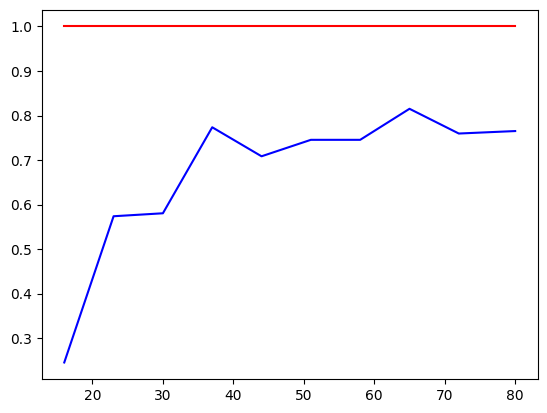

AdaBoost------------------------------------------
[[11  4]
 [ 3 10]]
Accuracy :  0.75
f1 score :  0.7407407407407407
              precision    recall  f1-score   support

           0       0.79      0.73      0.76        15
           1       0.71      0.77      0.74        13

    accuracy                           0.75        28
   macro avg       0.75      0.75      0.75        28
weighted avg       0.75      0.75      0.75        28



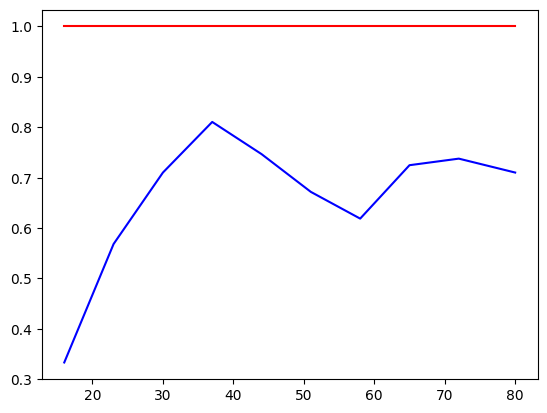

GradientBoosting----------------------------------
[[11  4]
 [ 2 11]]
Accuracy :  0.7857142857142857
f1 score :  0.7857142857142857
              precision    recall  f1-score   support

           0       0.85      0.73      0.79        15
           1       0.73      0.85      0.79        13

    accuracy                           0.79        28
   macro avg       0.79      0.79      0.79        28
weighted avg       0.79      0.79      0.79        28



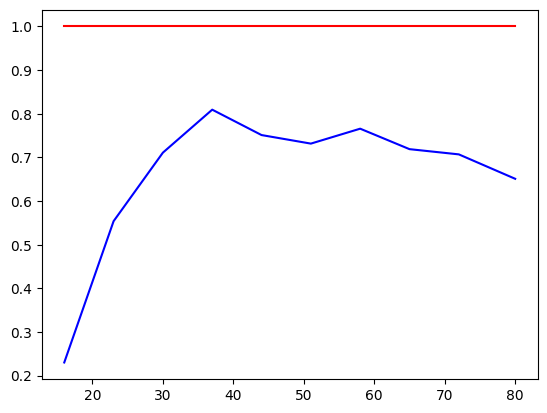

DecisionTree--------------------------------------
[[11  4]
 [ 4  9]]
Accuracy :  0.7142857142857143
f1 score :  0.6923076923076923
              precision    recall  f1-score   support

           0       0.73      0.73      0.73        15
           1       0.69      0.69      0.69        13

    accuracy                           0.71        28
   macro avg       0.71      0.71      0.71        28
weighted avg       0.71      0.71      0.71        28



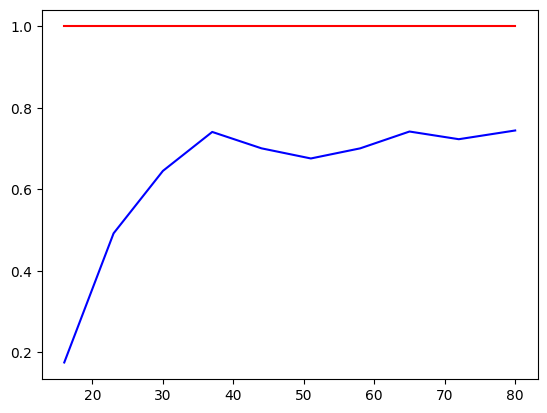

KNN-----------------------------------------------
[[14  1]
 [ 5  8]]
Accuracy :  0.7857142857142857
f1 score :  0.7272727272727273
              precision    recall  f1-score   support

           0       0.74      0.93      0.82        15
           1       0.89      0.62      0.73        13

    accuracy                           0.79        28
   macro avg       0.81      0.77      0.78        28
weighted avg       0.81      0.79      0.78        28



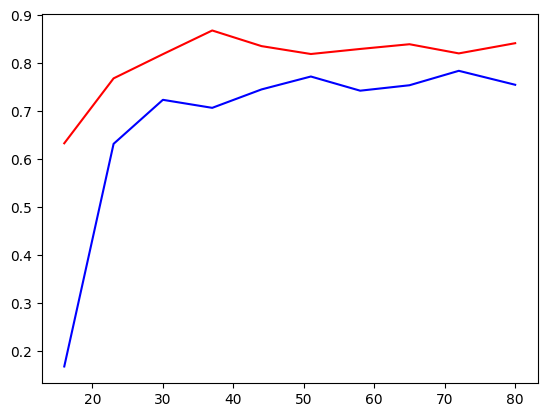

SVC-----------------------------------------------
[[14  1]
 [ 3 10]]
Accuracy :  0.8571428571428571
f1 score :  0.8333333333333334
              precision    recall  f1-score   support

           0       0.82      0.93      0.88        15
           1       0.91      0.77      0.83        13

    accuracy                           0.86        28
   macro avg       0.87      0.85      0.85        28
weighted avg       0.86      0.86      0.86        28



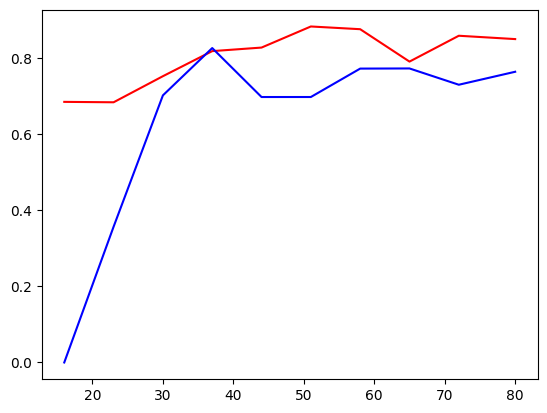

In [93]:
for name, each_model in dict_models.items():
    print(f"{name :-<50}")
    evaluation(each_model)

In [ ]:
# Extraction des noms des colonnes sélectionnées par SelectKBest
# Les noms originaux sont dans X_train.columns
selected_features = X_train.columns[model.named_steps['pipeline']['selectkbest'].get_support()]

# Extraction des importances du RandomForest
importances = model.named_steps['svc'].feature_importances_

# Création d'un DataFrame pour une lecture facile
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance (%)': importances * 100
}).sort_values(by='Importance (%)', ascending=False)

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(x=feature_importance_df['Feature'], height=feature_importance_df['Importance (%)'])
plt.xticks(rotation=90)
plt.ylabel('Importance (%)')
plt.title('Importance des variables sélectionnées')
plt.show()

On choisit le SVC comme meilleur modèle

In [94]:
SVC

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pipeline', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('selectkbest', ...), ('polynomialfeatures', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"score_func score_func: callable, default=f_classifFunction taking two arrays X and y, and returning a pair of arrays(scores, pvalues) or a single array with scores.Default is f_classif (see below ""See Also""). The default function onlyworks with classification tasks... versionadded:: 0.18",<function f_c...x7fe191f88900>
,"k k:

## OPTIMISATION DU MODÈLE

In [107]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [123]:
hyper_params = {
    'svc__C' : [1, 10, 100, 1000],
    'svc__kernel' : ['rbf', 'linear', 'sigmoid'],
    'svc__gamma' : ['scale', 1e-4, 1e-3, 1e-2, 1e-1],
    'pipeline__polynomialfeatures__degree' : range(2, 5),
    'pipeline__selectkbest__k' : range(4, 100)
}

In [124]:
grid = RandomizedSearchCV(SVC, hyper_params, scoring='recall', cv=4, random_state=321, n_iter=40)

In [125]:
grid.fit(X_train, y_train)

/home/harold/Documents/CODESPACE/Projects/COVID_19 - DATA SCIENCE PROJECT/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=19 is greater than n_features=17. All the features will be returned.
  warnings.warn(
/home/harold/Documents/CODESPACE/Projects/COVID_19 - DATA SCIENCE PROJECT/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=19 is greater than n_features=17. All the features will be returned.
  warnings.warn(
/home/harold/Documents/CODESPACE/Projects/COVID_19 - DATA SCIENCE PROJECT/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=19 is greater than n_features=17. All the features will be returned.
  warnings.warn(
/home/harold/Documents/CODESPACE/Projects/COVID_19 - DATA SCIENCE PROJECT/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=19 is greater than n_f

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=321))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'pipeline__polynomialfeatures__degree': range(2, 5), 'pipeline__selectkbest__k': range(4, 100), 'svc__C': [1, 10, ...], 'svc__gamma': ['scale', 0.0001, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation 

In [126]:
print(grid.best_params_)

{'svc__kernel': 'rbf', 'svc__gamma': 0.001, 'svc__C': 1, 'pipeline__selectkbest__k': 49, 'pipeline__polynomialfeatures__degree': 4}


In [127]:
y_pred = grid.predict(X_test)
print(classification_report(y_pred=y_pred, y_true=y_test))

              precision    recall  f1-score   support

           0       0.74      0.93      0.82        15
           1       0.89      0.62      0.73        13

    accuracy                           0.79        28
   macro avg       0.81      0.77      0.78        28
weighted avg       0.81      0.79      0.78        28



/home/harold/Documents/CODESPACE/Projects/COVID_19 - DATA SCIENCE PROJECT/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=49 is greater than n_features=17. All the features will be returned.
  warnings.warn(
/home/harold/Documents/CODESPACE/Projects/COVID_19 - DATA SCIENCE PROJECT/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=49 is greater than n_features=17. All the features will be returned.
  warnings.warn(
/home/harold/Documents/CODESPACE/Projects/COVID_19 - DATA SCIENCE PROJECT/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=49 is greater than n_features=17. All the features will be returned.
  warnings.warn(
/home/harold/Documents/CODESPACE/Projects/COVID_19 - DATA SCIENCE PROJECT/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=49 is greater than n_f

[[14  1]
 [ 5  8]]
Accuracy :  0.7857142857142857
f1 score :  0.7272727272727273
              precision    recall  f1-score   support

           0       0.74      0.93      0.82        15
           1       0.89      0.62      0.73        13

    accuracy                           0.79        28
   macro avg       0.81      0.77      0.78        28
weighted avg       0.81      0.79      0.78        28



/home/harold/Documents/CODESPACE/Projects/COVID_19 - DATA SCIENCE PROJECT/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=49 is greater than n_features=17. All the features will be returned.
  warnings.warn(
/home/harold/Documents/CODESPACE/Projects/COVID_19 - DATA SCIENCE PROJECT/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=49 is greater than n_features=17. All the features will be returned.
  warnings.warn(
/home/harold/Documents/CODESPACE/Projects/COVID_19 - DATA SCIENCE PROJECT/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=49 is greater than n_features=17. All the features will be returned.
  warnings.warn(
/home/harold/Documents/CODESPACE/Projects/COVID_19 - DATA SCIENCE PROJECT/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=49 is greater than n_f

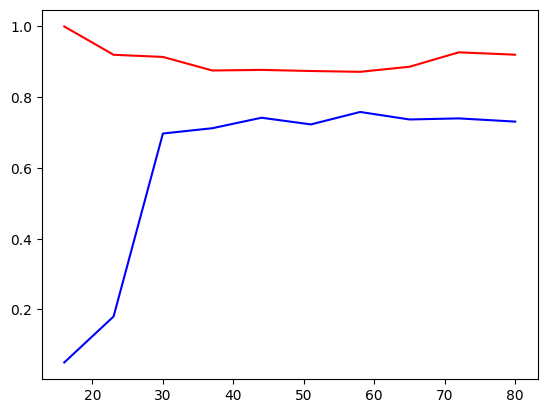

In [128]:
evaluation(grid.best_estimator_ )

In [164]:
from sklearn.metrics import precision_recall_curve, recall_score, precision_score

In [131]:
precision, recall, threshold = precision_recall_curve(y_test, grid.best_estimator_.decision_function(X_test))

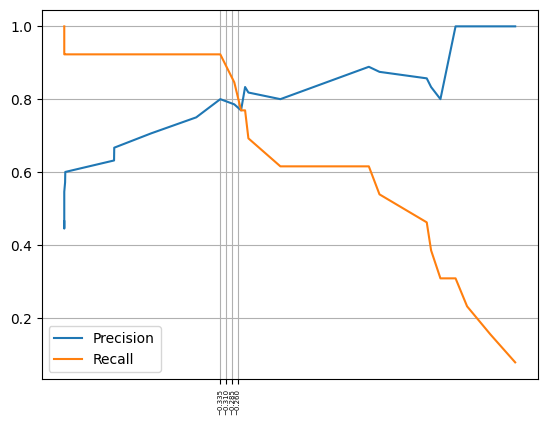

In [156]:
plt.figure()
plt.grid()
plt.xticks(np.arange(-0.335, -0.25, 0.025), rotation=90, fontsize=5)
plt.plot(threshold, precision[:-1], label="Precision")
plt.plot(threshold, recall[:-1], label="Recall")
plt.legend()
plt.show()

In [169]:
def model_final(model_, x_, threshold_: float=0):
    return model_.decision_function(x_) > threshold_

In [170]:
y_pred = model_final(grid.best_estimator_, X_test, threshold_=-0.335)

In [171]:
f1_score(y_test, y_pred)

0.8571428571428571

In [172]:
recall_score(y_test, y_pred)

0.9230769230769231

In [173]:
precision_score(y_test, y_pred)

0.8

In [175]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       0.80      0.92      0.86        13

    accuracy                           0.86        28
   macro avg       0.86      0.86      0.86        28
weighted avg       0.87      0.86      0.86        28

